Link Video : https://drive.google.com/drive/folders/1lojVNStBPOaP65cin8Uj65gATOqaiNRa?usp=drive_link

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data/Common_Rust/Corn_Common_Rust (454).JPG
/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data/Common_Rust/Corn_Common_Rust (365).JPG
/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data/Common_Rust/Corn_Common_Rust (585).JPG
/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data/Common_Rust/Corn_Common_Rust (1171).JPG
/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data/Common_Rust/Corn_Common_Rust (1181).JPG
/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data/Common_Rust/Corn_Common_Rust (739).JPG
/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data/Common_Rust/Corn_Common_Rust (1151).JPG
/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data/Common_Rust/Corn_Common_Rust (399).JPG
/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data/Common_Rust/Corn_Common_Rust (914).JPG
/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data/Common_Rust/Corn_Common_Rust (283).JPG
/kaggle/input/datasets/lunaaaaaa45454

## Load dataset

In [73]:
train_dir='/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data'

# ambil semua class label
categories=[d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir,d))]

print("Categories:", categories)

# hitung jumlah gambar perclass
for category in categories:
    category_path = os.path.join(train_dir, category)
    num_files = len([f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))])
    print(f"Number of files in {category}: {num_files}")

Categories: ['Common_Rust', 'Blight', 'Healthy', 'Gray_Leaf_Spot']
Number of files in Common_Rust: 1306
Number of files in Blight: 1146
Number of files in Healthy: 1162
Number of files in Gray_Leaf_Spot: 574


## tampilkan gambar

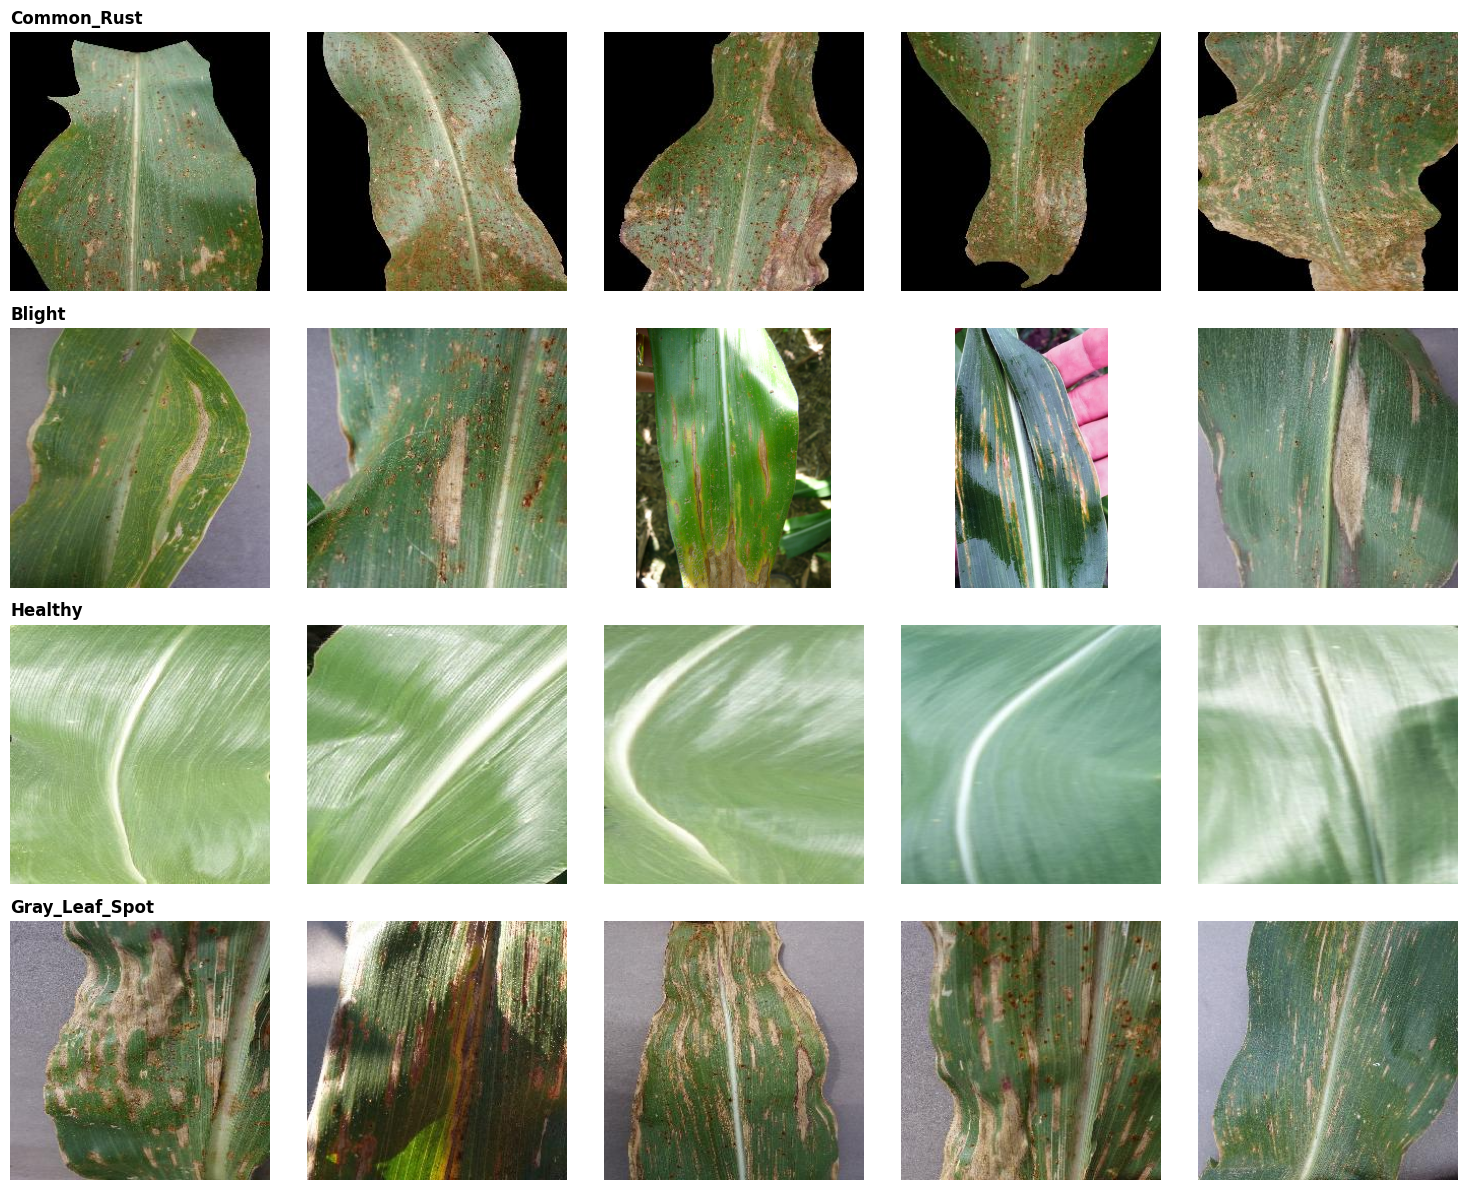

In [74]:
n_samples=5
fig, axes=plt.subplots(len(categories),n_samples,figsize=(n_samples*3, len(categories)*3))

for row, category in enumerate(categories):
    category_path = os.path.join(train_dir, category)
    files = [f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path, f))]
    samples = random.sample(files, min(n_samples, len(files)))
    
    for col, fname in enumerate(samples):
        img = mpimg.imread(os.path.join(category_path, fname))
        ax = axes[row][col] if len(categories) > 1 else axes[col]
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_title(category, fontsize=12, fontweight='bold', loc='left')

plt.tight_layout()
plt.show()

# EDA : cek aspect ratio & resolution

In [75]:
from collections import defaultdict
all_data= []
for category in categories:
    category_path=os.path.join(train_dir,category)
    files=[f for f in os.listdir(category_path) if os.path.isfile(os.path.join(category_path,f))]
    for fname in files:
        try:
            img=mpimg.imread(os.path.join(category_path,fname))
            h,w=img.shape[:2]
            all_data.append({'category': category,'width': w,'height': h,'aspect_ratio': round(w / h, 3)})
        except Exception:
            pass

by_category = defaultdict(list)
for d in all_data:
    by_category[d['category']].append(d)

# summary table
print(f"{'Category':<20} {'Count':>6} {'Most Common Res':>18} {'AR Mean':>9} {'AR Unique':>10}")
print("-"*68)
for cat in sorted(by_category.keys()):
    items = by_category[cat]
    resolutions = [(i['width'], i['height']) for i in items]
    most_common_res = max(set(resolutions), key=resolutions.count)
    ar_mean = np.mean([i['aspect_ratio'] for i in items])
    ar_unique = len(set(i['aspect_ratio'] for i in items))
    print(f"{cat:<20} {len(items):>6} {str(most_common_res):>18} {ar_mean:>9.3f} {ar_unique:>10}")

Category              Count    Most Common Res   AR Mean  AR Unique
--------------------------------------------------------------------
Blight                 1146         (256, 256)     1.033        100
Common_Rust            1306         (256, 256)     1.033         66
Gray_Leaf_Spot          574         (256, 256)     1.036         48
Healthy                1162         (256, 256)     1.000          1


- most common resolusi (256,256) berarti mayoritas rasio gambar square dan konsisten untuk semua class
- AR (ratio) mendekati 1 berarti hampir semua gambar kotak
- AR unique healthy = 1 berarti semua gambar di healthy ukuran dan proporsinya mirip. Ini berarti class healthy datanya konsisten dan mudah dipelajari. Kalau class yang lain banyak variasinya jadi lebih kompleks

# split

In [76]:
import os
import shutil
import random
from pathlib import Path

# config
SOURCE_DIR='/kaggle/input/datasets/lunaaaaaa4545455/no2utsdl/2D/data'
OUTPUT_DIR='/kaggle/working/split_data'
SPLITS={'train': 0.70, 'val': 0.15, 'test': 0.15}
SEED=42
random.seed(SEED)

# split
split_counts=defaultdict(lambda: defaultdict(int))

for category in categories:
    src_category=os.path.join(SOURCE_DIR, category)
    files=[f for f in os.listdir(src_category) if os.path.isfile(os.path.join(src_category, f))]
    random.shuffle(files) #diacak biar ga bias

    n=len(files)
    n_train=int(n*SPLITS['train'])
    n_val=int(n*SPLITS['val'])

    split_files = {
        'train': files[:n_train],
        'val':   files[n_train:n_train + n_val],
        'test':  files[n_train + n_val:]
    }

    for split, flist in split_files.items():
        dest_dir=os.path.join(OUTPUT_DIR, split, category)
        os.makedirs(dest_dir, exist_ok=True)
        for fname in flist:
            shutil.copy2(os.path.join(src_category, fname), os.path.join(dest_dir, fname))
        split_counts[split][category]=len(flist)

# summary
print(f"{'Category':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print("-" * 52)
for cat in sorted(categories):
    tr = split_counts['train'][cat]
    va = split_counts['val'][cat]
    te = split_counts['test'][cat]
    print(f"{cat:<20} {tr:>8} {va:>8} {te:>8} {tr+va+te:>8}")

print("-" * 52)
tr_tot = sum(split_counts['train'].values())
va_tot = sum(split_counts['val'].values())
te_tot = sum(split_counts['test'].values())
total  = tr_tot + va_tot + te_tot
print(f"{'TOTAL':<20} {tr_tot:>8} {va_tot:>8} {te_tot:>8} {total:>8}")
print(f"{'Ratio':<20} {tr_tot/total:>7.1%} {va_tot/total:>7.1%} {te_tot/total:>7.1%}")

Category                Train      Val     Test    Total
----------------------------------------------------
Blight                    802      171      173     1146
Common_Rust               914      195      197     1306
Gray_Leaf_Spot            401       86       87      574
Healthy                   813      174      175     1162
----------------------------------------------------
TOTAL                    2930      626      632     4188
Ratio                  70.0%   14.9%   15.1%


# preprocessing

## encoding label dan resize resolusi

sesuai urutan class :  
0 = blight  
1 = common rust  
2 = gray leaf spot  
3 = healthy

In [77]:
from PIL import Image
SPLIT_DIR = '/kaggle/working/split_data'
IMG_SIZE = (224, 224)

def load_split(split_name):
    X, y = [], []
    split_path = os.path.join(SPLIT_DIR, split_name)
    class_names = sorted(os.listdir(split_path))
    
    for label, category in enumerate(class_names):
        cat_path = os.path.join(split_path, category)
        if not os.path.isdir(cat_path):
            continue
        files = [f for f in os.listdir(cat_path) if os.path.isfile(os.path.join(cat_path, f))]
        for fname in files:
            img = Image.open(os.path.join(cat_path, fname)).convert('RGB')
            img = img.resize(IMG_SIZE)
            X.append(np.array(img)) #convert gambar jd array
            y.append(label) #simpen label yg udh di encode
    
    return np.array(X), np.array(y)


X_train, y_train = load_split('train')
X_val, y_val = load_split('val')
X_test, y_test = load_split('test')

## normalisasi/scaling

pixel awal : 0-255 -> di scale jadi 0-1 untuk training

In [78]:
X_train = X_train / 255.0
X_val   = X_val   / 255.0
X_test  = X_test  / 255.0

## hasil mapping dari encoding

In [79]:
class_names = sorted([d for d in os.listdir(os.path.join(SPLIT_DIR, 'train'))
                      if os.path.isdir(os.path.join(SPLIT_DIR, 'train', d))])
print(f"\nClass mapping: { {name: i for i, name in enumerate(class_names)} }")
print(f"\nX_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}  y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}  y_test:  {y_test.shape}")


Class mapping: {'Blight': 0, 'Common_Rust': 1, 'Gray_Leaf_Spot': 2, 'Healthy': 3}

X_train: (2930, 224, 224, 3)  y_train: (2930,)
X_val:   (626, 224, 224, 3)  y_val:   (626,)
X_test:  (632, 224, 224, 3)  y_test:  (632,)


# Baseline Model AlexNet

In [80]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_alexnet(input_shape=(224, 224, 3), num_classes=4):
    modelAlexNet = models.Sequential([
        # Block 1
        layers.Conv2D(96, kernel_size=11, strides=4, padding='valid', activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=3, strides=2),

        # Block 2
        layers.Conv2D(256, kernel_size=5, strides=1, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=3, strides=2),

        # Block 3
        layers.Conv2D(384, kernel_size=3, strides=1, padding='same', activation='relu'),

        # Block 4
        layers.Conv2D(384, kernel_size=3, strides=1, padding='same', activation='relu'),

        # Block 5
        layers.Conv2D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=3, strides=2),

        # Flatten
        layers.Flatten(),

        # FC 1
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        # FC 2
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),

        # Output —> adapted:4 classes(softmax)
        layers.Dense(num_classes, activation='softmax')
    ])
    return modelAlexNet

## build + compile model

In [81]:
modelAlexNet = build_alexnet(input_shape=(224, 224, 3), num_classes=4)
modelAlexNet.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,763,396 (178.39 MB)

 Trainable params: 46,763,396 (178.39 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
modelAlexNet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## training 20 epochs

In [83]:
history_alex = modelAlexNet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - accuracy: 0.4075 - loss: 1.2062 - val_accuracy: 0.5879 - val_loss: 0.8296
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.7029 - loss: 0.6483 - val_accuracy: 0.8546 - val_loss: 0.4524
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.7973 - loss: 0.4695 - val_accuracy: 0.8195 - val_loss: 0.4356
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.8273 - loss: 0.4059 - val_accuracy: 0.8482 - val_loss: 0.3689
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8460 - loss: 0.3660 - val_accuracy: 0.8658 - val_loss: 0.3489
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8551 - loss: 0.3574 - val_accuracy: 0.8003 - val_loss: 0.3759
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8597 - loss: 0.3292 - val_accuracy: 0.8722 - val_loss: 0.3061
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8830 - loss: 0.3030 - val_accuracy: 0.8754 -

## grafik train dan loss

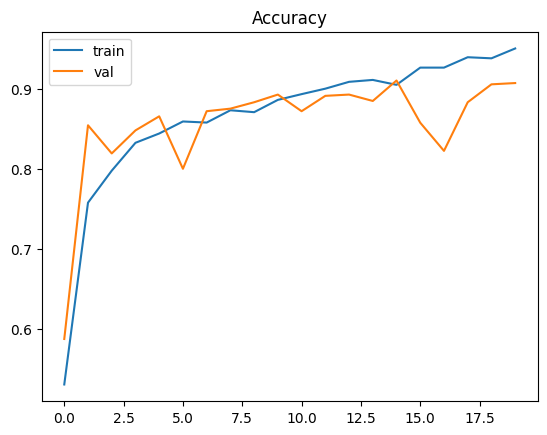

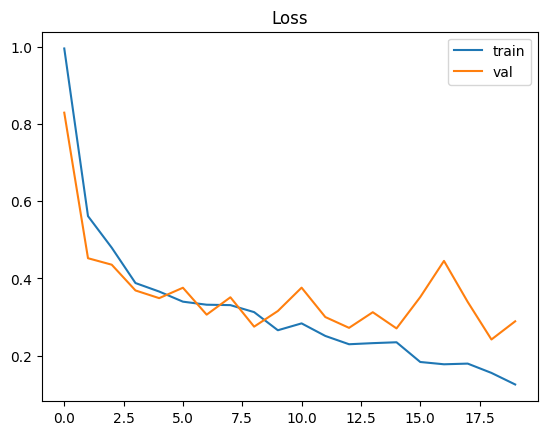

In [84]:
plt.plot(history_alex.history['accuracy'], label='train')
plt.plot(history_alex.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history_alex.history['loss'], label='train')
plt.plot(history_alex.history['val_loss'], label='val')
plt.legend()
plt.title('Loss')
plt.show()

Analisis hasil training : 
- Accuracy : Model berhasil generalize dengan baik karena grafik train terus naik dan grafik val mengikuti train dengan gap yang cukup kecil.
- Loss : grafik train nya turun secara stabil, begitu juga dengan grafik val(walaupun agak fluktuatif akibat proses awal training yang masih wajar). Penurunan loss ini berarti model semakin akurat. Karena diakhir epoch train agak turun, dan val agak naik, artinya model overfit ringan.

# Model 2 modifikasi cnn

Modifikasi yang dilakukan : 
- menggunakan convolution bertingkat (32, 64, 128) supaya dapat menangkap fitur secara lebih kompleks
- menambah batch normalization agar training lebih stabil dan konvergensi lebih cepat
- menggunakan maxpooling untuk mengurangi dimensi dan fokus pada fitur yang penting
- menggunakan global average pooling untuk menggantikan flatten untuk mengurangi overfitting
- menambah dropout untuk mencegah overfitting
- menggunakan callback earlystopping untuk stop kalo ga improve, dan reducelronplateu untuk menurunkan learning rate saat stuck
- menggunakan model checkpoint untuk menyimpan model dengan performa terbaik selama training sehingga hasil yang digunakan adalah model yang optimal

In [85]:
from tensorflow.keras import models,layers
n_classes = 4

modelEff = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    
    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Third Convolution Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Fourth Convolution Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Global Average Pooling
    layers.GlobalAveragePooling2D(),

    # Dense Layers
    layers.Dropout(0.2),  
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

In [86]:
modelEff.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,756 (979.52 KB)

 Trainable params: 250,052 (976.77 KB)

 Non-trainable params: 704 (2.75 KB)

## compile

In [87]:
modelEff.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [88]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.1,
    patience=3,
    verbose=1
)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

callbacks = [early_stopping, reduce_lr, model_checkpoint]

## training

In [89]:
history_eff = modelEff.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    verbose=1,
    callbacks=callbacks  
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 130ms/step - accuracy: 0.7505 - loss: 0.6409 - val_accuracy: 0.2780 - val_loss: 3.1822 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.8695 - loss: 0.3239 - val_accuracy: 0.2780 - val_loss: 4.3446 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.8942 - loss: 0.2862 - val_accuracy: 0.3387 - val_loss: 1.8420 - learning_rate: 0.0010
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9091 - loss: 0.2539 - val_accuracy: 0.6358 - val_loss: 0.8557 - learning_rate: 0.0010
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9155 - loss: 0.2113 - val_accuracy: 0.7268 - val_loss: 0.6927 - learning_rate: 0.0010
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9116 - loss: 0.2384 - val_accuracy: 0.8243 - val_loss: 0.4816 - learning_rate: 0.0010
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.9233 - loss: 0.1923 - val_a

## grafik train & loss

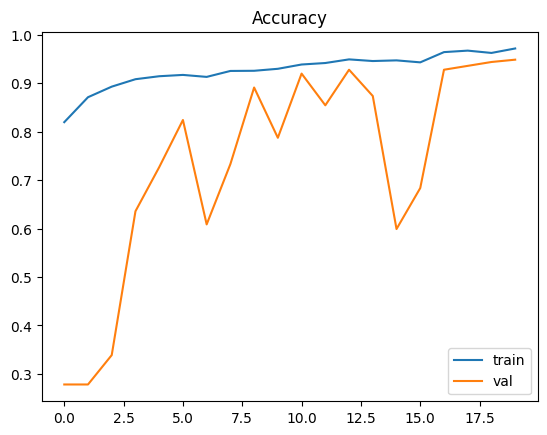

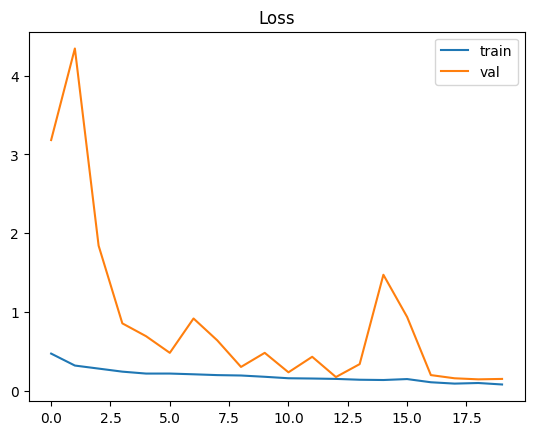

In [90]:
plt.plot(history_eff.history['accuracy'], label='train')
plt.plot(history_eff.history['val_accuracy'], label='val')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(history_eff.history['loss'], label='train')
plt.plot(history_eff.history['val_loss'], label='val')
plt.legend()
plt.title('Loss')
plt.show()

Analisa hasil training : 
- Accuracy : peningkatan grafik val sangat tajam diawal (0.3 ke 0.9) yang menandakan model cepat belajar. Lalu grafik validation naik secara stabil dan lebih tinggi dibandingkan model sebelumnya. Ini menandakan generalisasi model baru yang lebih baik dari model sebelumnya
- Loss : Penurunan loss yang drastis di awal val menunjukkan model cepat belajar. Setelah itu, validation loss bergerak stabil diakhir(menunjukkan bahwa model sudah konvergen) dan memiliki gap yang sangat kecil dengan train yang menandakan model tidak overfit.

# Evaluasi performa

## AlexNet model

In [91]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    cohen_kappa_score, matthews_corrcoef,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

class_names = ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
num_classes = len(class_names)

alex_y_prob = modelAlexNet.predict(X_test)
alex_y_pred = np.argmax(alex_y_prob, axis=1)
y_true = y_test

y_true_bin = label_binarize(y_true, classes=range(num_classes))

# metrics
alex_test_loss, alex_test_acc = modelAlexNet.evaluate(X_test, y_test, verbose=0)

print("=" * 60)
print("  EVALUATION METRICS — AlexNet Baseline")
print("=" * 60)
print(f"\n[1] Overall Test Accuracy : {alex_test_acc*100:.2f}%")
print(f"    Overall Test Loss      : {alex_test_loss:.4f}")
print("\n[1] Per-Class Classification Report:")
print(classification_report(y_true, alex_y_pred, target_names=class_names, digits=4))

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
  EVALUATION METRICS — AlexNet Baseline

[1] Overall Test Accuracy : 92.25%
    Overall Test Loss      : 0.7411

[1] Per-Class Classification Report:
                precision    recall  f1-score   support

        Blight     0.8290    0.9249    0.8743       173
   Common_Rust     0.9894    0.9442    0.9662       197
Gray_Leaf_Spot     0.8267    0.7126    0.7654        87
       Healthy     0.9943    1.0000    0.9972       175

      accuracy                         0.9225       632
     macro avg     0.9098    0.8954    0.9008       632
  weighted avg     0.9244    0.9225    0.9220       632



Analisis model 1 :
- Hasil accuracy yang cukup tinggi(92.25%) dan hasil loss yang tidak terlalu besar(0.74) menunjukkan bahwa model sudah cukup baik dalam mengklasifikasikan data, walaupun masih ada error.
- Hasil F1, recall, dan precision gray leaf spot cukup rendah dibandingkan class yang lain yang menandakan model kesulitan untuk memprediksi gray leaf spot



## confusion matrix alexnet

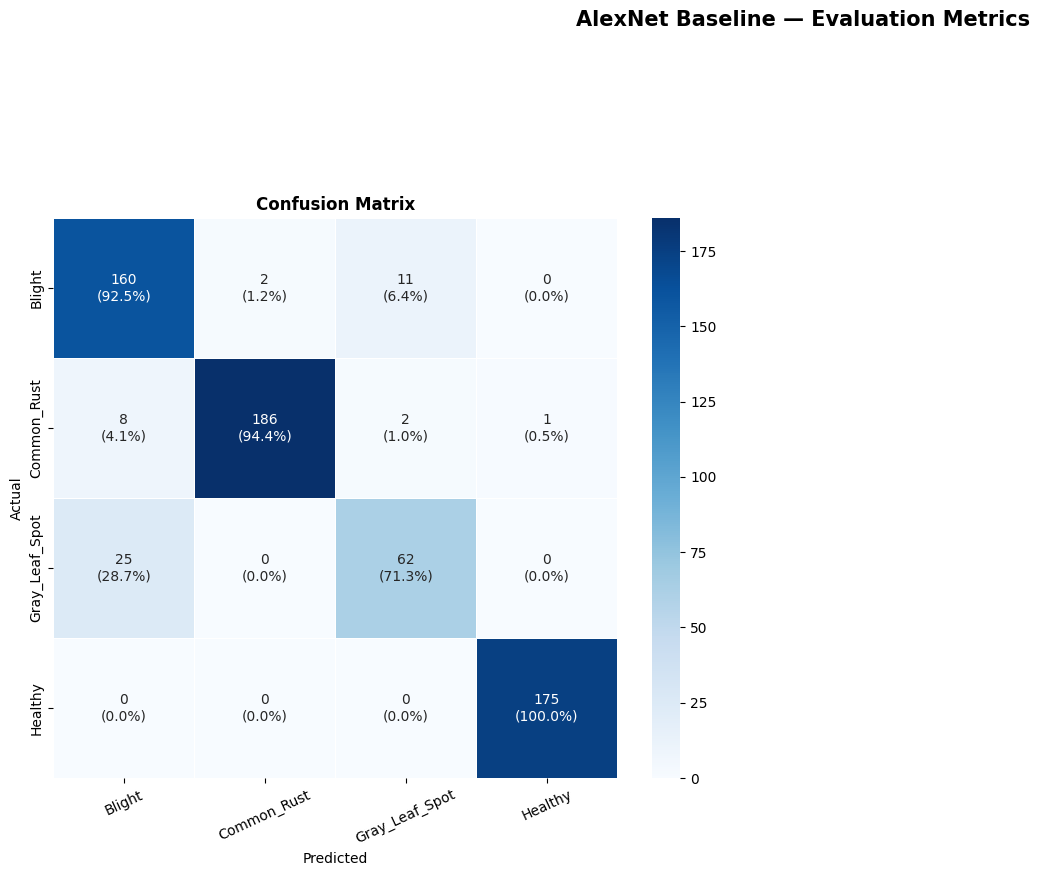

In [92]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('AlexNet Baseline — Evaluation Metrics', fontsize=15, fontweight='bold', y=1.01)

# confusion matrix
ax1 = fig.add_subplot(2, 2, 1)
cm = confusion_matrix(y_true,alex_y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)"
                   for j in range(num_classes)] for i in range(num_classes)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax1)
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=25)

Analisis CM model baseline : 
- data yang seharusnya masuk ke class gray leaf spot sering salah predict menjadi blight sebesar 29%. Begitu juga sebaliknya, class blight sebanyak 6.4% diprediksi sebagai gray leaf spot
- hasil prediksi yang true positive  untuk class gray leaf spot(71.3%) lebih rendah dibandingkan class yang lain -> akibat jumlah data di gray leaf spot yang jauh lebih sedikit dibandingkan class lain

Artinya, model sulit untuk membedakan pola antara gray leaf spot vs blight.

## Modified model

In [93]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    cohen_kappa_score, matthews_corrcoef,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

class_names = ['Blight', 'Common_Rust', 'Gray_Leaf_Spot', 'Healthy']
num_classes = len(class_names)

# Predict
eff_y_prob = modelEff.predict(X_test)                      # (n, 4) probabilities
eff_y_pred = np.argmax(eff_y_prob, axis=1)                  # predicted class
y_true = y_test

y_true_bin = label_binarize(y_true, classes=range(num_classes))

# Accuracy, Precision, Recall, F1
eff_test_loss, eff_test_acc = modelEff.evaluate(X_test, y_test, verbose=0)

print("=" * 60)
print("  EVALUATION METRICS — Modified model")
print("=" * 60)
print(f"\n[1] Overall Test Accuracy : {eff_test_acc*100:.2f}%")
print(f"    Overall Test Loss      : {eff_test_loss:.4f}")
print("\n[1] Per-Class Classification Report:")
print(classification_report(y_true, eff_y_pred, target_names=class_names, digits=4))



20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
  EVALUATION METRICS — Modified model

[1] Overall Test Accuracy : 93.83%
    Overall Test Loss      : 0.1521

[1] Per-Class Classification Report:
                precision    recall  f1-score   support

        Blight     0.9367    0.8555    0.8943       173
   Common_Rust     0.9596    0.9645    0.9620       197
Gray_Leaf_Spot     0.8163    0.9195    0.8649        87
       Healthy     0.9831    1.0000    0.9915       175

      accuracy                         0.9383       632
     macro avg     0.9239    0.9349    0.9282       632
  weighted avg     0.9401    0.9383    0.9383       632



Analisis model 2 : 
- Nilai accuracy semakin naik(94%), dan loss semakin turun(0.15) yang berarti performa meningkat signifikan dibandingkan model baseline
- Gray leaf spot masih memiliki nilai yang lebih rendah(0.85) daripada class yang lain, namun meningkat cukup banyak dibandingkan pada model baseline

## Evaluation matrix modified model

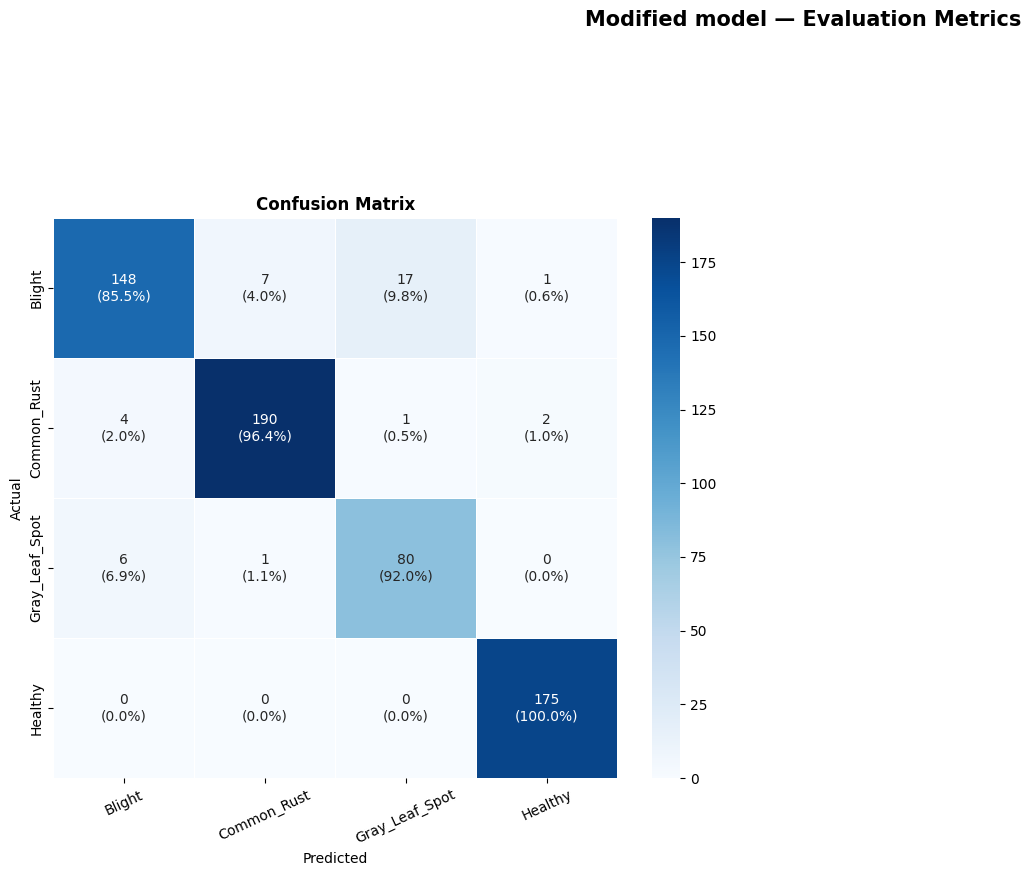

In [94]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Modified model — Evaluation Metrics', fontsize=15, fontweight='bold', y=1.01)

# confusion matrix
ax1 = fig.add_subplot(2, 2, 1)
cm = confusion_matrix(y_true, eff_y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)"
                   for j in range(num_classes)] for i in range(num_classes)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax1)
ax1.set_title('Confusion Matrix', fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=25)

Analisis CM model baru : 
- Kesalahan prediksi antar semakin berkurang, terutama prediksi blight pada data yang seharusnya gray leaf spot (dari 33% ke 6,9%)
- prediksi gray leaf spot semakin akurat (92%)

Artinya model mampu menangkap fitur yang penting pada tiap class sehingga kesalahan antar class berkurang.

Kesimpulan akhir : 
Dari hasil metric, model baseline AlexNet mampu mencapai akurasi sebesar 89.87% dengan performa yang cukup baik terutama pada class healthy dan common rust. Tapi, model baseline ini masih mengalami sulit mengklasifikasikan class gray leaf spot. Ini terlihat dari nilai F1-score yang lebih rendah dibandingkan class lain dan kesalahan klasifikasi yang cukup tinggi pada confusion matrix.

Setelah dilakukan modifikasi arsitektur model baseline dengan menambahkan batch normalization, dropout, serta penggunaan global average pooling, performa model meningkat secara signifikan. Model modifikasi berhasil mencapai akurasi sebesar 94.15% serta peningkatan pada nilai precision, recall, dan F1score dengan penurunan loss yang signifikan hingga 0.1. Peningkatan paling signifikan terjadi pada class gray leaf spot yang naik hingga F1score 0.86.

Kesimpulannya, modifikasi arsitektur berhasil meningkatkan kemampuan model dalam menangkap fitur yang lebih kompleks, sekaligus mengurangi overfitting, sehingga model memiliki kemampuan generalisasi yang lebih baik dibandingkan baseline. Dengan begitu, dapat disimpulkan bahwa model modifikasi memiliki performa yang baik dan dapat digunakan untuk pengembangan lebih lanjut.

Saran pengembangan : 
- Melakukan data augmentation
- Menyeimbangkan jumlah data antar kelas (bisa dengan teknik oversampling atau pemberian class weight)
- Eksperimen lebih lanjut untuk memodifikasi model dengan hyperparameter tuning
- Evaluasi lebih lanjut dengan metrik tambahan